# Univariate Analysis of Numerical Features

This notebook performs a univariate exploratory data analysis of the numerical
features in the IBM Telco Customer Churn dataset.

The analysis focuses on understanding the distribution, scale, missing values,
and potential outliers in individual numerical features prior to any cleaning
or transformation steps.

## Scope of Analysis

This notebook is intentionally limited to numerical features only.

Categorical features are validated at ingestion time and analyzed primarily
through feature–target relationships in a separate notebook. Restricting this
analysis to numerical variables allows for a focused assessment of statistical
properties that directly impact preprocessing and model stability.

No feature engineering, encoding, scaling, or modeling is performed here.


In [2]:
import sys
from pathlib import Path

# Add project root to PYTHONPATH
project_root = Path().resolve().parent
sys.path.append(str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import PROCESSED_DATA_PATH

plt.style.use("default")

In [12]:
data_path = PROCESSED_DATA_PATH / "telco_customer_churn_validated.csv"
df = pd.read_csv(data_path)

print(f"Shape of the data: {df.shape}")
df.head()

Shape of the data: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Numerical Features

The dataset contains a small set of numerical features related to customer
tenure and billing behavior. These features are analyzed individually in the
following sections to assess their distributions and data quality.

Only features with numeric meaning are included in this analysis.


In [16]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[numeric_cols] = pd.to_numeric(df[numeric_cols].stack(), errors="coerce").unstack()

## Distribution Analysis

This section examines the distribution of each numerical feature using
histograms. The goal is to identify skewness, spread, and any unusual patterns
that may require attention during data cleaning.


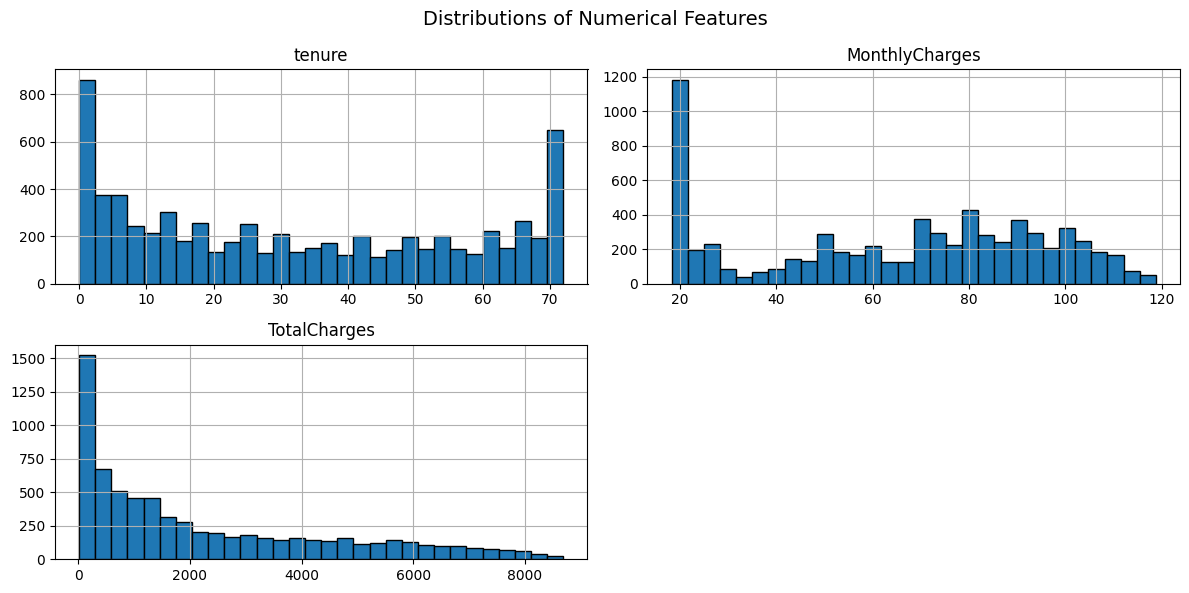

In [17]:
df[numeric_cols].hist(figsize=(12, 6), bins=30, edgecolor="black")
plt.suptitle("Distributions of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

### Distribution Insights

- `tenure` exhibits a non-normal distribution with a high concentration of
  customers at very low and very high values, reflecting early churn and
  long-term retention patterns.
- `MonthlyCharges` is right-skewed, with most customers clustered in lower
  pricing tiers and a smaller proportion paying higher monthly fees.
- `TotalCharges` shows a heavily right-skewed distribution with a large spike
  near zero, consistent with customers who have low or zero tenure.

Overall, the observed distributions are consistent with real-world customer
billing behavior but indicate the need for robust preprocessing, particularly
for skewed features and accumulated charges.


## Summary Statistics

Summary statistics provide quantitative insight into the central tendency,
variability, and range of numerical features. These statistics complement the
visual analysis and help identify skewed distributions or extreme values.


In [10]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


### Summary Statistics Insights

- `tenure` shows a wide spread with a median lower than the mean, indicating a
  right-skewed distribution and the presence of long-tenure customers.
- `MonthlyCharges` exhibits moderate skewness and a wide interquartile range,
  reflecting different pricing tiers across customers.
- `TotalCharges` displays strong right skewness, with a mean substantially higher
  than the median and a very large standard deviation, consistent with its
  cumulative nature.

Overall, the summary statistics reinforce the distributional findings and
highlight the need for robust preprocessing techniques, particularly for
skewed and accumulated features.


## Missing Value Analysis

This section evaluates the presence of missing values in numerical features.
Understanding missingness is essential for selecting appropriate imputation
strategies during preprocessing.


In [18]:
df[numeric_cols].isna().sum()

tenure             0
MonthlyCharges     0
TotalCharges      11
dtype: int64

In [20]:
df[df["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0.0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0.0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0.0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0.0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0.0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0.0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0.0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0.0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


### Missing Value Findings

- No missing values are observed in `tenure` or `MonthlyCharges`.
- `TotalCharges` contains a small number of missing values (11 observations).

Further inspection shows that these missing values correspond to customers with
zero tenure, where total charges are represented as empty strings in the raw
dataset. This results in missing values when the column is coerced to a numeric
type.

The missingness is minimal, non-random, and driven by data representation rather
than data loss.

## Outlier Detection

Potential outliers are examined using boxplots and the Interquartile Range (IQR)
method. At this stage, outliers are not removed; instead, their presence is
documented to inform downstream cleaning decisions.

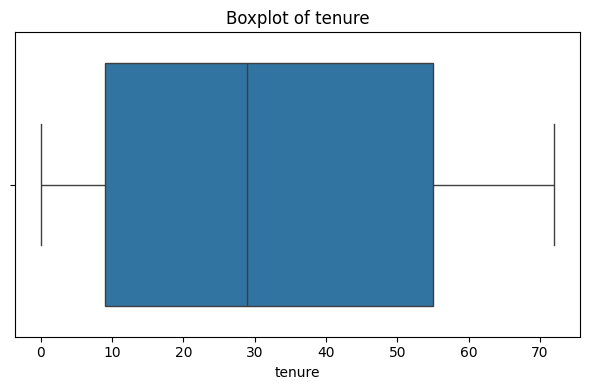

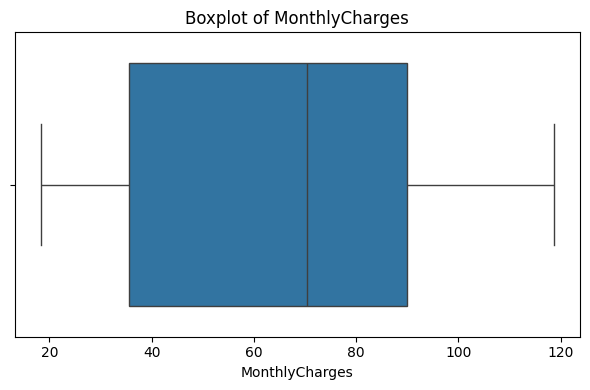

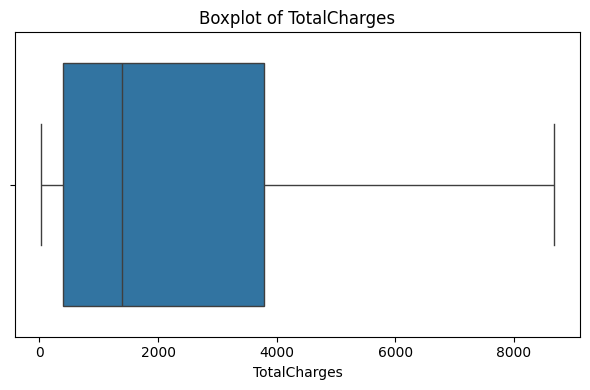

In [21]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

### Outlier Assessment

Based on the boxplots and the IQR criterion, no numerical feature exhibits
statistical outliers outside the whisker bounds.

Although `MonthlyCharges` and `TotalCharges` show skewed distributions and
large value ranges, all observed values fall within the expected interquartile
range limits. This indicates high variability rather than anomalous data points.

As a result, no observations are flagged for removal at this stage.

### Implications for Data Cleaning and Next Steps

The univariate analysis of numerical features leads to the following conclusions:

- All observations should be retained, as no IQR-defined statistical outliers
  were identified and missing values are minimal and explainable.
- The `TotalCharges` feature requires explicit conversion to a numeric type,
  after which a small number of structurally missing values should be imputed.
- Median-based imputation is appropriate given the skewed distributions and
  non-random nature of the missingness.
- Although no extreme outliers are present, the numerical features exhibit
  skewness and large value ranges, which should be addressed during
  preprocessing through robust scaling or transformation if required.

These findings inform the subsequent numeric data cleaning step, followed by
categorical cleaning and feature engineering in later stages of the pipeline.
